In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
import relativity as rety


Generando las funciones de plot y sympy para calculo simbolico (ejercicio 1 y 6)

In [2]:
def solve_simultaneity(ev1, ev2):
    t1, x1 = ev1
    t2, x2 = ev2
    c, v = sp.symbols('c v', real=True, positive=True)
    
    # Diferencias
    dt = t2 - t1
    dx = x2 - x1
    
    # Condición de simultaneidad: dt' = gamma*(dt - v*dx/c^2) = 0
    # Implica: dt - v*dx/c^2 = 0
    v_value = dt * c**2 / dx
    
    # Verificación de tipo de intervalo
    # Si abs(v) >= c, es imposible físicamente (Time-like o Light-like)
    is_possible = sp.simplify(sp.Abs(v_value) < c)
    
    return v_value, is_possible

def plot_minkowski(ax, events, beta, title):
    c = 1
    # Unpack events (x, ct)
    x_coords = [e[0] for e in events]
    ct_coords = [e[1] for e in events]

    # Determine plot limits based on events
    max_val = max(max(x_coords), max(ct_coords))
    limit = max_val * 2
    
    # Plot Light Cones (from origin)
    ax.plot([-limit, limit], [-limit, limit], 'k--', alpha=0.3, label='Cono de Luz')
    ax.plot([-limit, limit], [limit, -limit], 'k--', alpha=0.3)

    # Plot Events
    ax.scatter(x_coords, ct_coords, color='red', s=100, zorder=10, label='Eventos')
    for i, (x, ct) in enumerate(zip(x_coords, ct_coords)):
        ax.text(x, ct + 0.1, f'$E_{i+1}$', horizontalalignment='center', color='black', fontsize=12, fontweight='bold')

    # Line of Simultaneity passing through the events
    # This line represents t' = constant. Its slope is beta = v/c
    x_vals = np.linspace(-limit, limit, 100)
    # Line equation: ct - ct1 = m * (x - x1) where m = beta
    y_simul = beta * (x_vals - x_coords[0]) + ct_coords[0]
    ax.plot(x_vals, y_simul, 'g-', linewidth=2, label=f"Línea de Simultaneidad (Pendiente {beta})")

    # Worldline of K' observer (ct' axis)
    # Passes through origin (standard configuration)
    # Slope is 1/beta
    if beta != 0:
        y_worldline = (1/beta) * x_vals
        ax.plot(x_vals, y_worldline, 'b-.', label=f"Eje $ct'$ (Observador, $v={beta}c$)")
    
    # Grid and Setup
    ax.set_xlim(0, 3.5) 
    ax.set_ylim(0, 3.5)
    ax.set_xlabel('$x$ ($a$)', fontsize=12)
    ax.set_ylabel('$ct$ ($a$)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.legend(loc='upper right')
    ax.set_aspect('equal')
    
    # Add axes lines
    ax.axhline(0, color='black', linewidth=1)
    ax.axvline(0, color='black', linewidth=1)

Ejercicio 1. Dos eventos ocurren en un sistema inercial K de la siguiente manera:
- Evento 1: x1 = a, t1 = 2a/c, y1 = 0, z1 = 0
- Evento 2: x2 = 2a, t2 = 3a/2c, y2 =0, z2 = 0

¿En qué marco de referencia K ′ aparecerán estos eventos como simultáneos? Describe el movimiento del sistema K'.

Velocidad requerida para simultaneidad: -c/2


TypeError: cannot determine truth value of Relational: 2*a/c > 2*a

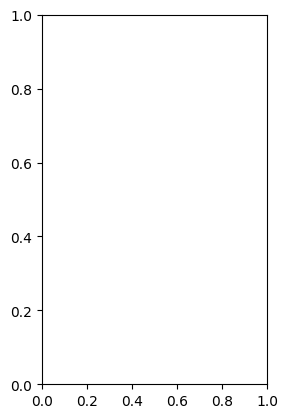

In [3]:
# --- Definición de Variables ---
a, c = sp.symbols('a c', real=True, positive=True)
# t1=2a/c, x1=a  |  t2=3a/(2c), x2=2a
v1, possible1 = solve_simultaneity((2*a/c, a), (3*a/(2*c), 2*a))

print(f"Velocidad requerida para simultaneidad: {v1}")
plot_minkowski(plt.subplot(1, 2, 1), [(a, 2*a/c), (2*a, 3*a/(2*c))], v1/c, "Simultaneidad de $E_1$ y $E_2$")

Ejercicio 2. Se envı́a una señal luminosa desde el origen de un sistema K en t = 0 hacia el punto x = 3 m, y =
5m, z = 10 m.
(a) ¿En qué tiempo t se recibe la señal?
(b) Encuentra (x′ , y ′ , z ′ , t′ ) para la recepción de la señal en un marco K ′ que se mueve a lo largo
del eje x de K a una velocidad de 0,8c.
(c) A partir de tus resultados en (b), verifica que la luz viajó con una velocidad c medida en el
marco K ′ .

In [ ]:
c = 299792458.0  # Velocidad de la luz
K = rety.ReferenceFrame("K", velocity=(0, 0, 0), c = c)  # Sistema de referencia K
K_prime = rety.ReferenceFrame("K'", velocity=(0.8*c, 0, 0), c = c) # Sistema de referencia K' moviéndose al 80% de la velocidad de la luz respecto a K

r = [3.0, 5.0, 10.0]  # Posición del evento en K
t1 = np.abs(np.linalg.norm(smart_array(r)))  # Tiempo del evento en K (asumiendo que la luz tarda el tiempo que tarda en llegar al evento)
t = float(t1)/c  # Redondeamos el tiempo a un número entero para simplificar
print(f"Tiempo calculado para la luz en K: {t} s")

llegada_senal = rety.Event(t, r, frame=K, c = c)  # Creamos el evento en el marco K
llegada_en_K_prime = llegada_senal.in_frame(K_prime)  # Transformamos el evento al marco K'
print(f"Tiempo en K: {llegada_senal.t} s")
print(f"Tiempo en K': {llegada_en_K_prime.t} s")
print(f"Posición en K: {llegada_senal.position} en metros")
print(f"Posición en K': {llegada_en_K_prime.position} en metros")

Tiempo calculado para la luz en K: 3.8612835626406004e-08 s
Tiempo en K: 3.8612835626406004e-08 s
Tiempo en K': 5.101216223608393e-08 s
Posición en K: [ 3.  5. 10.] en metros
Posición en K': [-10.4344492   5.         10.       ] en metros


Ejercicio 3. Un grupo de astrónomos descubre un planeta orbitando una estrella similar a nuestro sol que se encuentra a 20 años luz de distancia. ¿Qué tan rápido debe viajar una nave espacial si el viaje de ida y vuelta no debe durar más de 40 años para los astronautas a bordo? ¿Cuánto tiempo durará el viaje medido desde la Tierra?

In [ ]:
c = 1.0  # Velocidad de la luz en unidades naturales
L = 20
v = 0.707

t_earth = 40/v

Tierra = rety.ReferenceFrame("Tierra", velocity=(0, 0, 0), relative_to=None, c=c) # Sistema de referencia Tierra
E_depart = rety.Event(0, [0,0,0], Tierra, c) # Evento de partida en la Tierra
E_return = rety.Event(t_earth, [0,0,0], Tierra, c) # Evento de regreso a la Tierra

tau = E_depart.proper_time_to(E_return)
print(f"Tiempo propio del viajero: {tau} unidades de tiempo")


Tiempo propio del viajero: 56.577086280056584 unidades de tiempo


Ejercicio 4. Un mecanismo en la Tierra, diseñado para derribar satélites geoestacionarios que albergan armas
láser, es finalmente perfeccionado y propulsa pelotas de golf a 0,94c. (Los satélites geoestacionarios
se sitúan a 3,58 × 104 km sobre la superficie terrestre).
(a) ¿Cuál es la distancia de la Tierra al satélite, medida por un detector colocado dentro de la
pelota de golf?
(b) ¿Cuánto tiempo le tomará a la pelota de golf realizar el viaje hasta el satélite en el marco de
la Tierra? ¿Cuánto tiempo tomará en el marco de la pelota de golf?

In [ ]:
c = 299792458  # Velocidad de la luz en unidades naturales
Tierra = rety.ReferenceFrame("Tierra", velocity=(0, 0, 0), c=c)  # Sistema de referencia Tierra
pelota = rety.ReferenceFrame("Pelota", velocity=(0.94*c, 0, 0), relative_to=Tierra, c=c) # Sistema de referencia de la pelota
e1 = rety.Event(0, [0,0,0], Tierra, c)  # Evento 1 en la Tierra
e2 = rety.Event(0.94, [3.58e7,0,0], Tierra, c)  # Evento 2 en la Tierra (pelota se mueve a 0.94c)
l = e1.proper_length_to(e2)
print(f"Longitud propia entre los eventos: {l} unidades de longitud")   

ValueError: Intervalo no es space-like.

Ejercicio 7. Un observador S’ se mueve a 0.4c en dirección al eje x con respecto a un observador quieto en S. Una señal es emitida en el origen, a la misma dirección y tiene una frecuencia de 300 Hz medida por el observador en S. ¿cuál es la frecuencia medida por el observador en S’ ? ¿Sufre un blueshift o un redshift ?, Si el observador viene con la misma dirección hacia la luz, ¿qué frecuencia medirá?

In [ ]:
c = 1.0

# Marcos
S  = rety.ReferenceFrame("S",  [0,0,0], None, c)
Sp = rety.ReferenceFrame("S'", [0.4*c,0,0], S, c)

# Frecuencia
f = 300
omega = 2*np.pi*f

# Luz en +x
k = rety.FourWaveVector(omega/c, [omega/c, 0, 0])

# Frecuencia medida por S'
omega_p = k.frequency_measured_by(Sp)
f_p = omega_p/(2*np.pi)
print(f_p)

Sp2 = rety.ReferenceFrame("S''", [-0.4*c,0,0], S, c)

omega_p2 = k.frequency_measured_by(Sp2)
f_p2 = omega_p2/(2*np.pi)

print(f_p2)

196.39610121239315
458.25756949558394


Ejercicio 8. 

(a) Imagina que estás persiguiendo una partı́cula cósmica que va a una velocidad de 0,95c respecto
a un observador en reposo en el eje x. Si tu te mueves a una velocidad de 0,6c respecto al
mismo observador y en el eje x. ¿a qué velocidad se mueve la partı́cula respecto a ti?

(b) Ahora (ignorando la idea de que posees masa), imagina que te estás moviendo a la velocidad
de la luz y persigues a un fotón (cuánto de energı́a de la luz). ¿La luz se seguirá moviendo a
una velocidad c en tu marco de referencia? Argumente su respuesta.

In [ ]:
c = 1.0 
S = rety.ReferenceFrame('s', velocity = (0.0, 0.0, 0.0), c=c)
yo = rety.ReferenceFrame('yo', velocity = (0.6*c, 0.0, 0.0), c=c)

Ejercicio 9. En un futuro, se envı́a a la tripulación ARA a una misión en el planeta Berius a 30 años luz de la tierra. La tripulación va a una velocidad de 0,8c. Si tu estás en una nave que se mueve a 0,6c,
¿en cuánto tiempo llegará la tripulación ARA a Berius en tu marco de referencia?

In [ ]:

c = 1.0  # Velocidad de la luz en unidades naturales
tierra = rety.ReferenceFrame("Tierra", velocity=(0, 0, 0), c = c)  # Sistema de referencia de la Tierra
mi_nave = rety.ReferenceFrame("Mi Nave", velocity=(0.6, 0, 0), c = c) # Nave moviéndose al 80% de la velocidad de la luz respecto a la Tierra

llegada_ARA = rety.Event(37.5, [30.0, 0.0, 0.0], frame=tierra, c = c)  # Evento de llegada a destino en el marco de la Tierra
desde_mi_nave = llegada_ARA.in_frame(mi_nave)  # Transformamos el evento al marco de la nave

print(f"{desde_mi_nave.t} años" )  # Tiempo del evento en el marco de la nave

24.375 años


In [ ]:
c = 1.0
S = rety.ReferenceFrame('s', velocity = (0.0, 0.0, 0.0), c=c)
proton = rety.ReferenceFrame('protón', velocity = (0.8*c, 0.0, 0.0), relative_to=S, c=c)
antiproton = rety.ReferenceFrame('antiprotón', velocity = (-0.8*c, 0.0, 0.0), relative_to=S, c=c)
print("Velocidad del protón respecto al antiproton:", antiproton.velocity_wrt(proton)[0],"c")
print("Velocidad del antiproton respecto al protón:", proton.velocity_wrt(antiproton)[0],"c")

Velocidad del protón respecto al antiproton: -0.975609756097561 c
Velocidad del antiproton respecto al protón: 0.975609756097561 c
